Cell 1 — Import & Setup

In [10]:
import os
import sys
from pathlib import Path

if Path(os.getcwd()).name == "notebooks":
    os.chdir("..")

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import Counter

from src.utils import load_config, set_seed

# Đọc cấu hình từ thư mục gốc
cfg = load_config("config.yaml")
set_seed(cfg["training"]["seed"])

# Đường dẫn chuẩn xác theo cấu hình dự án
TRAIN_DIR = Path(cfg["data"]["raw_dir"]) / "Training"
TEST_DIR  = Path(cfg["data"]["raw_dir"]) / "Testing"
CLASSES   = cfg["data"]["classes"]
FIG_DIR   = Path("outputs/figures/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Setup và sửa lỗi đường dẫn hoàn tất!")
print(f"   Thư mục hoạt động hiện tại: {os.getcwd()}")
print(f"   Train dir : {TRAIN_DIR}")
print(f"   Test dir  : {TEST_DIR}")

✅ Setup và sửa lỗi đường dẫn hoàn tất!
   Thư mục hoạt động hiện tại: c:\Users\Thang\source\repos\brain-tumor-classification
   Train dir : data\Training
   Test dir  : data\Testing


Cell 2 — Đếm số lượng ảnh từng class

In [3]:
from src.dataset import get_dataloaders
from tqdm import tqdm

cfg["training"]["num_workers"] = 0

print("⏳ Đang tạo DataLoader (Phân chia Train/Val/Test)...")
train_loader, val_loader, test_loader, class_to_idx, idx_to_class = get_dataloaders(cfg)

def count_from_loader(loader, desc):
    counts = {cls: 0 for cls in CLASSES}
    # Bọc loader bằng tqdm để hiển thị thanh tiến trình trực quan
    for _, labels in tqdm(loader, desc=desc, leave=False):
        for label in labels.numpy():
            counts[idx_to_class[label]] += 1
    return counts

print("\n⏳ Đang đếm ảnh thực tế trong từng tập (Mất khoảng 10-20 giây)...")
train_counts = count_from_loader(train_loader, "Quét tập Train")
val_counts   = count_from_loader(val_loader, "Quét tập Val") 
test_counts  = count_from_loader(test_loader, "Quét tập Test")

print("\n" + "=" * 55)
print(f"  {'Class':<15} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("=" * 55)
for cls in CLASSES:
    total = train_counts[cls] + val_counts[cls] + test_counts[cls]
    print(f"  {cls:<15} {train_counts[cls]:>8} {val_counts[cls]:>8} {test_counts[cls]:>8} {total:>8}")
print("=" * 55)

⏳ Đang tạo DataLoader (Phân chia Train/Val/Test)...
[Dataset] Quét thư mục Training...
  [glioma] 1321 ảnh
  [meningioma] 1339 ảnh
  [notumor] 1595 ảnh
  [pituitary] 1457 ảnh
  → Tổng: 5712 ảnh

[Phân bố dữ liệu]
  glioma               1321 ảnh
  meningioma           1339 ảnh
  notumor              1595 ảnh
  pituitary            1457 ảnh

[Dataset] Quét thư mục Testing...
  [glioma] 300 ảnh
  [meningioma] 306 ảnh
  [notumor] 405 ảnh
  [pituitary] 300 ảnh
  → Tổng: 1311 ảnh

[Split] Train: 4855 | Val: 857 | Test: 1311

⏳ Đang đếm ảnh thực tế trong từng tập (Mất khoảng 10-20 giây)...



  Class              Train      Val     Test    Total
  glioma              1123      198      300     1621
  meningioma          1138      201      306     1645
  notumor             1356      239      405     2000
  pituitary           1238      219      300     1757


Cell 3 — Biểu đồ phân bố số lượng ảnh

C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\2605079617.py:47: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\2605079617.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
c:\Users\Thang\source\repos\brain-tumor-classification\env_mri\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


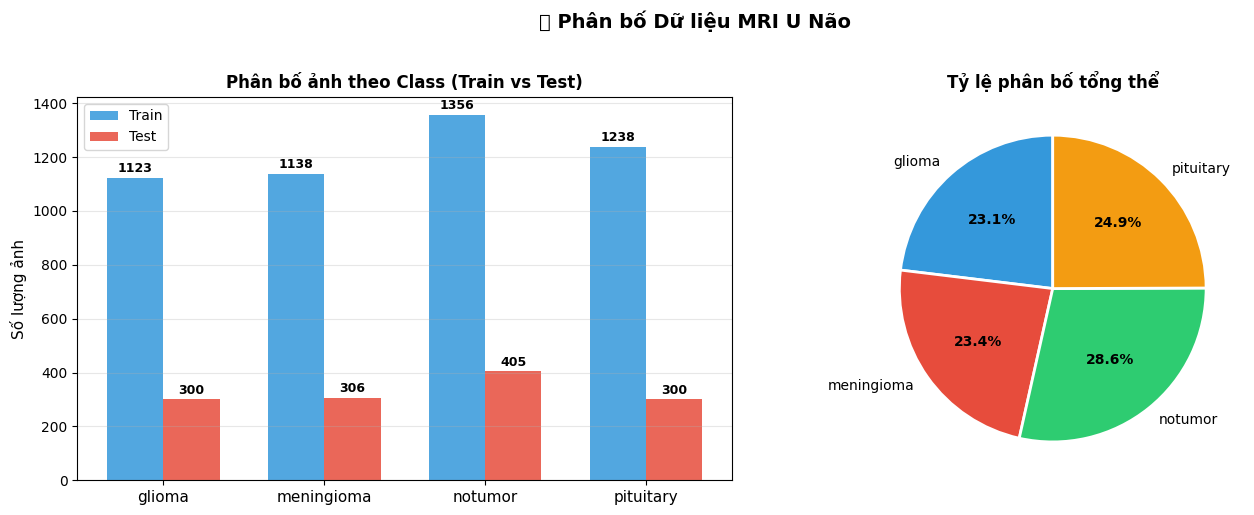

[Saved] → outputs\figures\eda\class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x        = np.arange(len(CLASSES))
width    = 0.35
colors   = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]

# ── Grouped bar chart ─────────────────────────────────────────── #
bars1 = axes[0].bar(x - width/2,
                    [train_counts[c] for c in CLASSES],
                    width, label="Train", color="#3498db", alpha=0.85)
bars2 = axes[0].bar(x + width/2,
                    [test_counts[c] for c in CLASSES],
                    width, label="Test",  color="#e74c3c", alpha=0.85)

for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 10,
                 str(int(bar.get_height())),
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASSES, fontsize=11)
axes[0].set_ylabel("Số lượng ảnh", fontsize=11)
axes[0].set_title("Phân bố ảnh theo Class (Train vs Test)",
                   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

# ── Pie chart tổng thể ────────────────────────────────────────── #
totals = [train_counts[c] + test_counts[c] for c in CLASSES]
wedges, texts, autotexts = axes[1].pie(
    totals,
    labels=CLASSES,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")

axes[1].set_title("Tỷ lệ phân bố tổng thể", fontsize=12, fontweight="bold")

plt.suptitle("📊 Phân bố Dữ liệu MRI U Não", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Saved] → {FIG_DIR / 'class_distribution.png'}")

Cell 4 — Xem ảnh mẫu từng class

C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\538599720.py:49: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\538599720.py:50: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
c:\Users\Thang\source\repos\brain-tumor-classification\env_mri\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


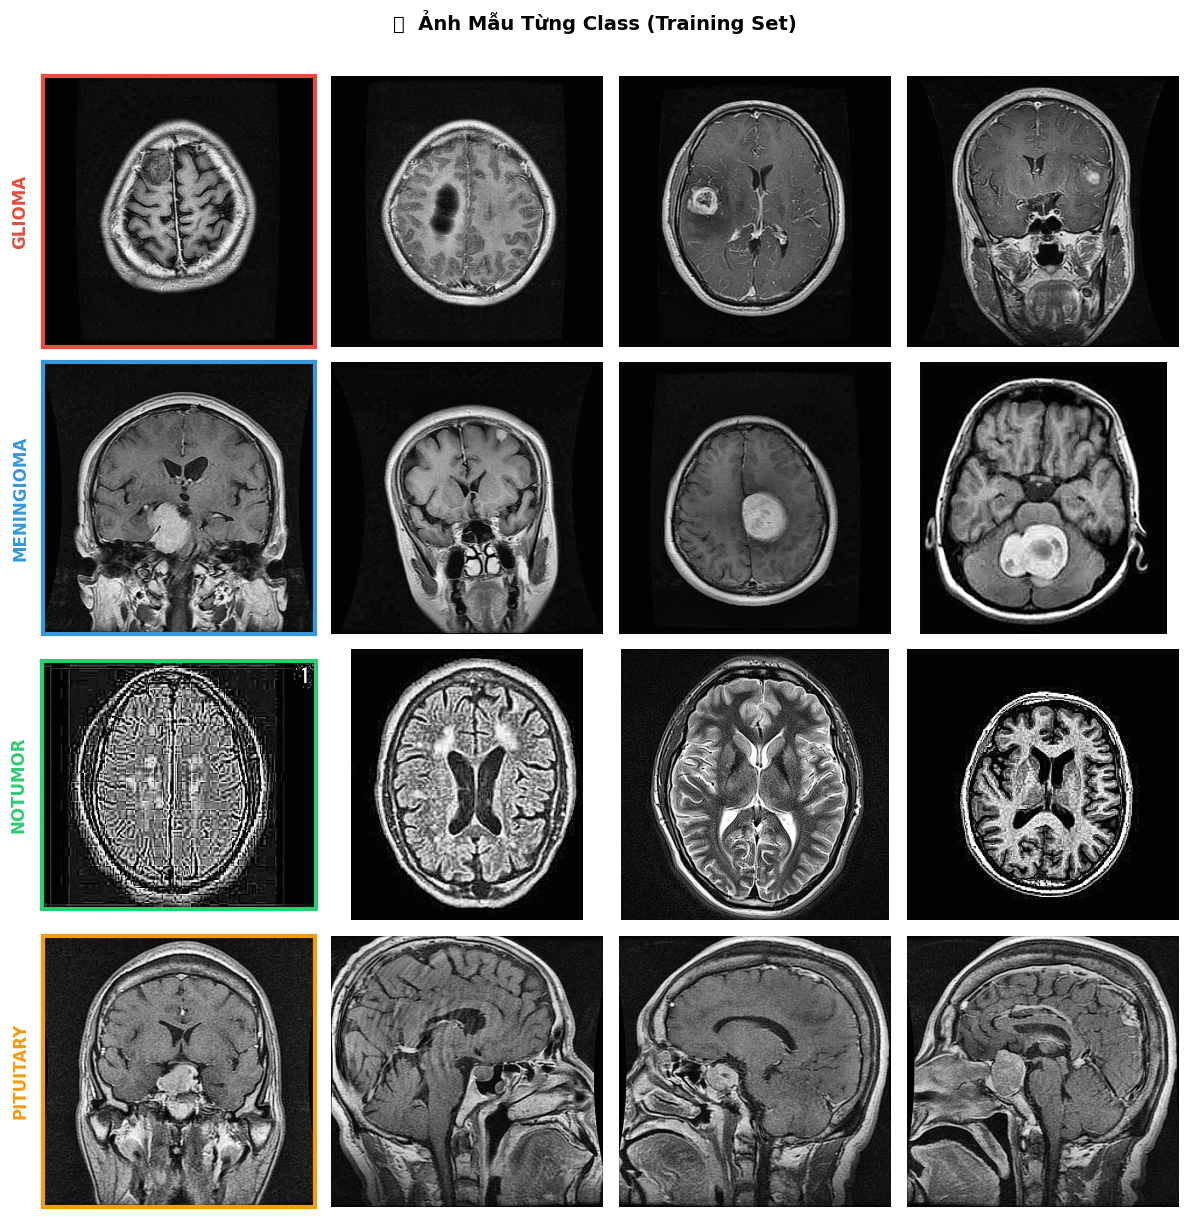

[Saved] → outputs\figures\eda\sample_images.png


In [5]:
def get_sample_images(base_dir: Path, classes: list, n: int = 4) -> dict:
    """Lấy ngẫu nhiên n ảnh mỗi class"""
    samples = {}
    for cls in classes:
        cls_dir = base_dir / cls
        if not cls_dir.exists():
            # Thử khớp không phân biệt hoa/thường
            for folder in base_dir.iterdir():
                if folder.name.lower() == cls.lower():
                    cls_dir = folder
                    break
        all_imgs = [f for f in os.listdir(cls_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        chosen   = random.sample(all_imgs, min(n, len(all_imgs)))
        samples[cls] = [cls_dir / img for img in chosen]
    return samples

N_SAMPLES = 4
samples   = get_sample_images(TRAIN_DIR, CLASSES, N_SAMPLES)

fig, axes = plt.subplots(len(CLASSES), N_SAMPLES,
                          figsize=(N_SAMPLES * 3, len(CLASSES) * 3))

class_colors = {"glioma":      "#e74c3c",
                "meningioma":  "#3498db",
                "notumor":     "#2ecc71",
                "pituitary":   "#f39c12"}

for row, cls in enumerate(CLASSES):
    for col, img_path in enumerate(samples[cls]):
        img = Image.open(img_path).convert("RGB")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(
                cls.upper(), fontsize=12, fontweight="bold",
                color=class_colors.get(cls, "black"),
                rotation=90, labelpad=10
            )
            axes[row, col].axis("on")
            axes[row, col].set_yticks([])
            axes[row, col].set_xticks([])
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor(class_colors.get(cls, "black"))
                spine.set_linewidth(3)

plt.suptitle("🖼️  Ảnh Mẫu Từng Class (Training Set)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[Saved] → {FIG_DIR / 'sample_images.png'}")

Cell 5 — Phân tích kích thước ảnh

⏳ Đang quét kích thước ảnh...


C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\1687525102.py:61: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\1687525102.py:62: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "image_sizes.png", dpi=150, bbox_inches="tight")
c:\Users\Thang\source\repos\brain-tumor-classification\env_mri\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


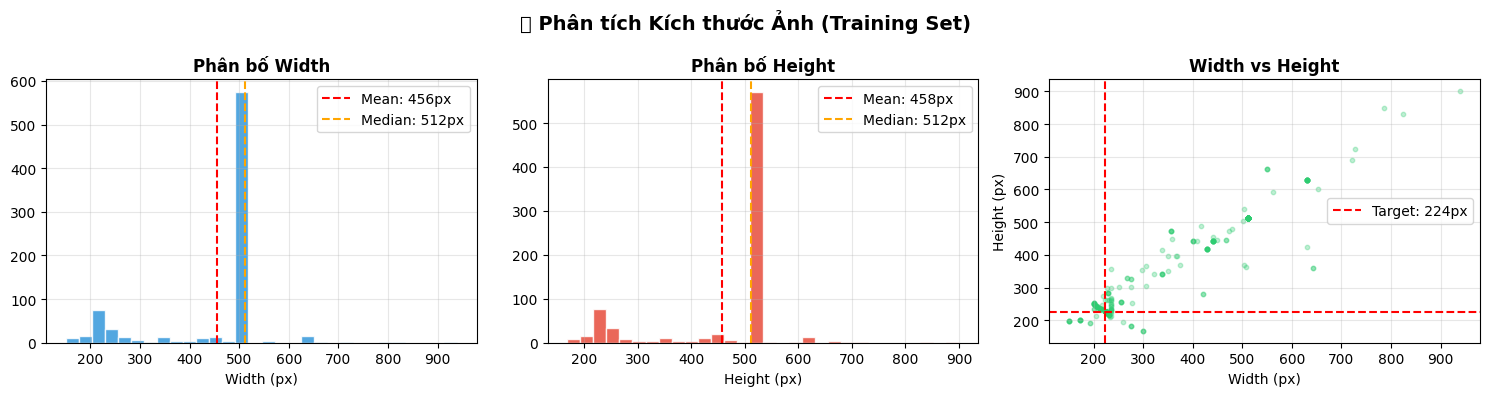


[Thống kê kích thước]
  Width  — min: 150  max: 940  mean: 455.5
  Height — min: 168  max: 900  mean: 457.7

  Top 5 kích thước phổ biến nhất:
    512x512px — 571 ảnh
    225x225px — 36 ảnh
    630x630px — 12 ảnh
    228x221px — 9 ảnh
    428x417px — 8 ảnh


In [6]:
def collect_image_sizes(base_dir: Path, classes: list,
                         max_per_class: int = 200) -> dict:
    """Thu thập width, height của ảnh trong dataset"""
    widths, heights = [], []
    for cls in classes:
        cls_dir = base_dir / cls
        if not cls_dir.exists():
            for folder in base_dir.iterdir():
                if folder.name.lower() == cls.lower():
                    cls_dir = folder
                    break
        imgs = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        imgs = random.sample(imgs, min(max_per_class, len(imgs)))
        for img_name in imgs:
            w, h = Image.open(cls_dir / img_name).size
            widths.append(w)
            heights.append(h)
    return {"widths": widths, "heights": heights}

print("⏳ Đang quét kích thước ảnh...")
sizes = collect_image_sizes(TRAIN_DIR, CLASSES)
W, H  = sizes["widths"], sizes["heights"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Histogram Width ───────────────────────────────────────────── #
axes[0].hist(W, bins=30, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(np.mean(W), color="red",    linestyle="--",
                label=f"Mean: {np.mean(W):.0f}px")
axes[0].axvline(np.median(W), color="orange", linestyle="--",
                label=f"Median: {np.median(W):.0f}px")
axes[0].set_title("Phân bố Width", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Width (px)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Histogram Height ──────────────────────────────────────────── #
axes[1].hist(H, bins=30, color="#e74c3c", edgecolor="white", alpha=0.85)
axes[1].axvline(np.mean(H), color="red",    linestyle="--",
                label=f"Mean: {np.mean(H):.0f}px")
axes[1].axvline(np.median(H), color="orange", linestyle="--",
                label=f"Median: {np.median(H):.0f}px")
axes[1].set_title("Phân bố Height", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Height (px)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Scatter Width vs Height ───────────────────────────────────── #
axes[2].scatter(W, H, alpha=0.3, s=10, color="#2ecc71")
axes[2].axvline(224, color="red",  linestyle="--", label="Target: 224px")
axes[2].axhline(224, color="red",  linestyle="--")
axes[2].set_title("Width vs Height", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("📐 Phân tích Kích thước Ảnh (Training Set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "image_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n[Thống kê kích thước]")
print(f"  Width  — min: {min(W)}  max: {max(W)}  mean: {np.mean(W):.1f}")
print(f"  Height — min: {min(H)}  max: {max(H)}  mean: {np.mean(H):.1f}")
unique_sizes = Counter(zip(W, H)).most_common(5)
print(f"\n  Top 5 kích thước phổ biến nhất:")
for size, cnt in unique_sizes:
    print(f"    {size[0]}x{size[1]}px — {cnt} ảnh")

Cell 6 — Phân tích độ sáng (Brightness) từng class

⏳ Đang tính độ sáng...


C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\359630346.py:49: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\359630346.py:50: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "brightness_distribution.png", dpi=150)
c:\Users\Thang\source\repos\brain-tumor-classification\env_mri\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


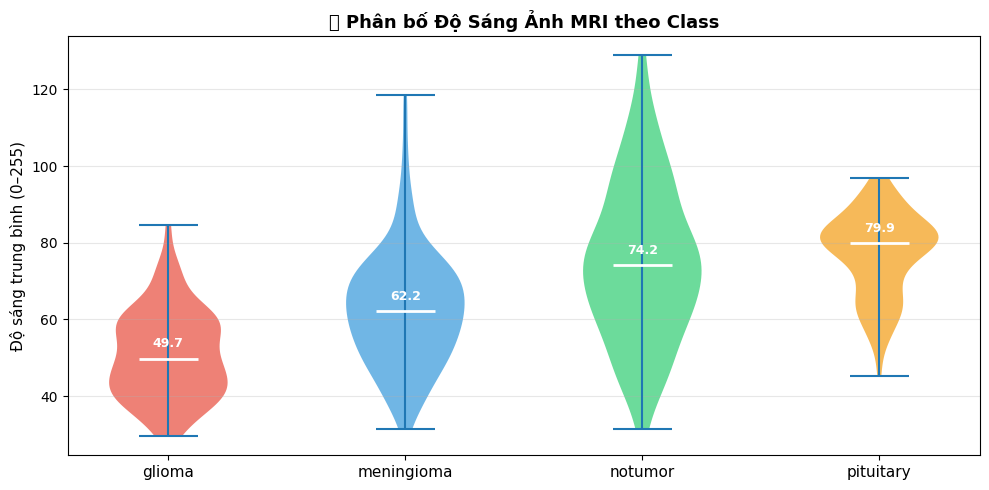

[Saved] → outputs\figures\eda\brightness_distribution.png


In [7]:
def mean_brightness(img_path) -> float:
    """Tính độ sáng trung bình của ảnh (grayscale)"""
    img = Image.open(img_path).convert("L")   # Grayscale
    return np.array(img).mean()

print("⏳ Đang tính độ sáng...")
brightness_data = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    cls_dir = TRAIN_DIR / cls
    if not cls_dir.exists():
        for folder in TRAIN_DIR.iterdir():
            if folder.name.lower() == cls.lower():
                cls_dir = folder
                break
    imgs = [f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    imgs = random.sample(imgs, min(150, len(imgs)))
    for img_name in imgs:
        brightness_data[cls].append(mean_brightness(cls_dir / img_name))

# ── Violin plot ───────────────────────────────────────────────── #
fig, ax = plt.subplots(figsize=(10, 5))
data_list  = [brightness_data[cls] for cls in CLASSES]
colors     = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

parts = ax.violinplot(data_list, positions=range(len(CLASSES)),
                       showmedians=True, showextrema=True)

for i, (pc, color) in enumerate(zip(parts["bodies"], colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

parts["cmedians"].set_color("white")
parts["cmedians"].set_linewidth(2)

ax.set_xticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, fontsize=11)
ax.set_ylabel("Độ sáng trung bình (0–255)", fontsize=11)
ax.set_title("🔆 Phân bố Độ Sáng Ảnh MRI theo Class",
              fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

for i, cls in enumerate(CLASSES):
    med = np.median(brightness_data[cls])
    ax.text(i, med + 3, f"{med:.1f}", ha="center",
            fontsize=9, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig(FIG_DIR / "brightness_distribution.png", dpi=150)
plt.show()
print(f"[Saved] → {FIG_DIR / 'brightness_distribution.png'}")

Cell 7 — Pixel Intensity Distribution (histogram màu)

⏳ Đang tính toán phân bố điểm ảnh toàn bộ các lớp...


C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\575357357.py:38: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thang\AppData\Local\Temp\ipykernel_69504\575357357.py:39: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "pixel_intensity.png", dpi=150)
c:\Users\Thang\source\repos\brain-tumor-classification\env_mri\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


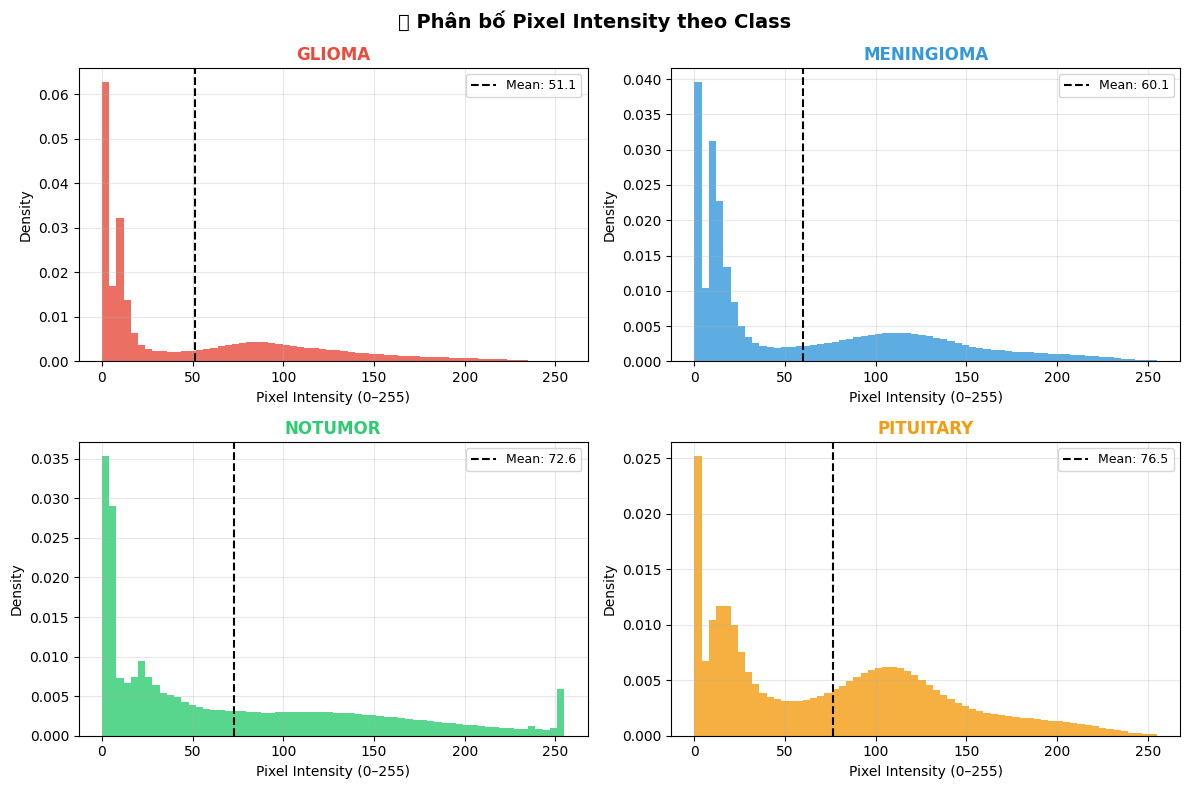

[Saved] → outputs\figures\eda\pixel_intensity.png


In [8]:
def sample_pixel_values(base_dir: Path, cls: str, n_imgs: int = 50) -> np.ndarray:
    """Lấy mẫu giá trị pixel từ N ảnh của 1 class - Phiên bản tối ưu hóa tốc độ và RAM"""
    cls_dir = base_dir / cls
    if not cls_dir.exists():
        for folder in base_dir.iterdir():
            if folder.name.lower() == cls.lower():
                cls_dir = folder
                break
                
    imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    imgs = random.sample(imgs, min(n_imgs, len(imgs)))
    
    pixels = []
    for img_name in imgs:
        arr = np.array(Image.open(cls_dir / img_name).convert("L"))
        # TỐI ƯU: Lưu trực tiếp mảng numpy, không chuyển thành list thuần
        pixels.append(arr.flatten()) 
        
    # Gộp tất cả các mảng lại bằng hàm tối ưu của numpy
    return np.concatenate(pixels)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes      = axes.flatten()
colors    = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

print("⏳ Đang tính toán phân bố điểm ảnh toàn bộ các lớp...")
for ax, cls, color in zip(axes, CLASSES, colors):
    pixels = sample_pixel_values(TRAIN_DIR, cls)
    ax.hist(pixels, bins=64, color=color, alpha=0.8, density=True)
    ax.axvline(pixels.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {pixels.mean():.1f}")
    ax.set_title(f"{cls.upper()}", fontsize=12, fontweight="bold", color=color)
    ax.set_xlabel("Pixel Intensity (0–255)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("🎨 Phân bố Pixel Intensity theo Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "pixel_intensity.png", dpi=150)
plt.show()
print(f"[Saved] → {FIG_DIR / 'pixel_intensity.png'}")

Cell 8 — Tổng kết EDA

In [9]:
print("=" * 55)
print("  📋 TỔNG KẾT EDA")
print("=" * 55)

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())
total_all   = total_train + total_test

print(f"\n  Tổng ảnh Training : {total_train:,}")
print(f"  Tổng ảnh Testing  : {total_test:,}")
print(f"  Tổng cộng         : {total_all:,}")

print(f"\n  Tỷ lệ mất cân bằng (train):")
max_count = max(train_counts.values())
for cls in CLASSES:
    ratio = train_counts[cls] / max_count
    bar   = "█" * int(ratio * 20)
    print(f"    {cls:<15} {train_counts[cls]:>5}  {bar}")

print(f"\n  Kích thước ảnh sau resize : 224 × 224 px")
print(f"  Số kênh màu               : 3 (RGB)")
print(f"  Normalize                 : ImageNet mean/std")

print(f"\n  Augmentation (Training):")
print(f"    ✅ RandomHorizontalFlip(p=0.5)")
print(f"    ✅ RandomRotation(±15°)")
print(f"    ✅ ColorJitter(brightness, contrast)")

print(f"\n  Figures đã lưu tại: {FIG_DIR}/")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"    📊 {f.name}")

print("\n" + "=" * 55)
print("  ✅ EDA hoàn tất — sẵn sàng sang 02_training.ipynb")
print("=" * 55)

  📋 TỔNG KẾT EDA

  Tổng ảnh Training : 4,855
  Tổng ảnh Testing  : 1,311
  Tổng cộng         : 6,166

  Tỷ lệ mất cân bằng (train):
    glioma           1123  ████████████████
    meningioma       1138  ████████████████
    notumor          1356  ████████████████████
    pituitary        1238  ██████████████████

  Kích thước ảnh sau resize : 224 × 224 px
  Số kênh màu               : 3 (RGB)
  Normalize                 : ImageNet mean/std

  Augmentation (Training):
    ✅ RandomHorizontalFlip(p=0.5)
    ✅ RandomRotation(±15°)
    ✅ ColorJitter(brightness, contrast)

  Figures đã lưu tại: outputs\figures\eda/
    📊 brightness_distribution.png
    📊 class_distribution.png
    📊 image_sizes.png
    📊 pixel_intensity.png
    📊 sample_images.png

  ✅ EDA hoàn tất — sẵn sàng sang 02_training.ipynb
